In [21]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np
import pandas as pd

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Useful tools for averaging cv results
import composable.records as rec

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay

## Activity 3.3

In [3]:
(folds := StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [4]:
(my_scores := ['accuracy',
          'balanced_accuracy',
          'f1',
          'precision',
          'recall',
          'roc_auc',
          ])

['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall', 'roc_auc']

In [5]:
(diabetes :=
 pl.read_csv('./sample_data/diabetes_raw.csv'))

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
i64,i64,i64,i64,i64,f64,f64,i64,str
6,148,72,35,0,33.6,0.627,50,"""Yes"""
1,85,66,29,0,26.6,0.351,31,"""No"""
8,183,64,0,0,23.3,0.672,32,"""Yes"""
1,89,66,23,94,28.1,0.167,21,"""No"""
0,137,40,35,168,43.1,2.288,33,"""Yes"""
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,"""No"""
2,122,70,27,0,36.8,0.34,27,"""No"""
5,121,72,23,112,26.2,0.245,30,"""No"""


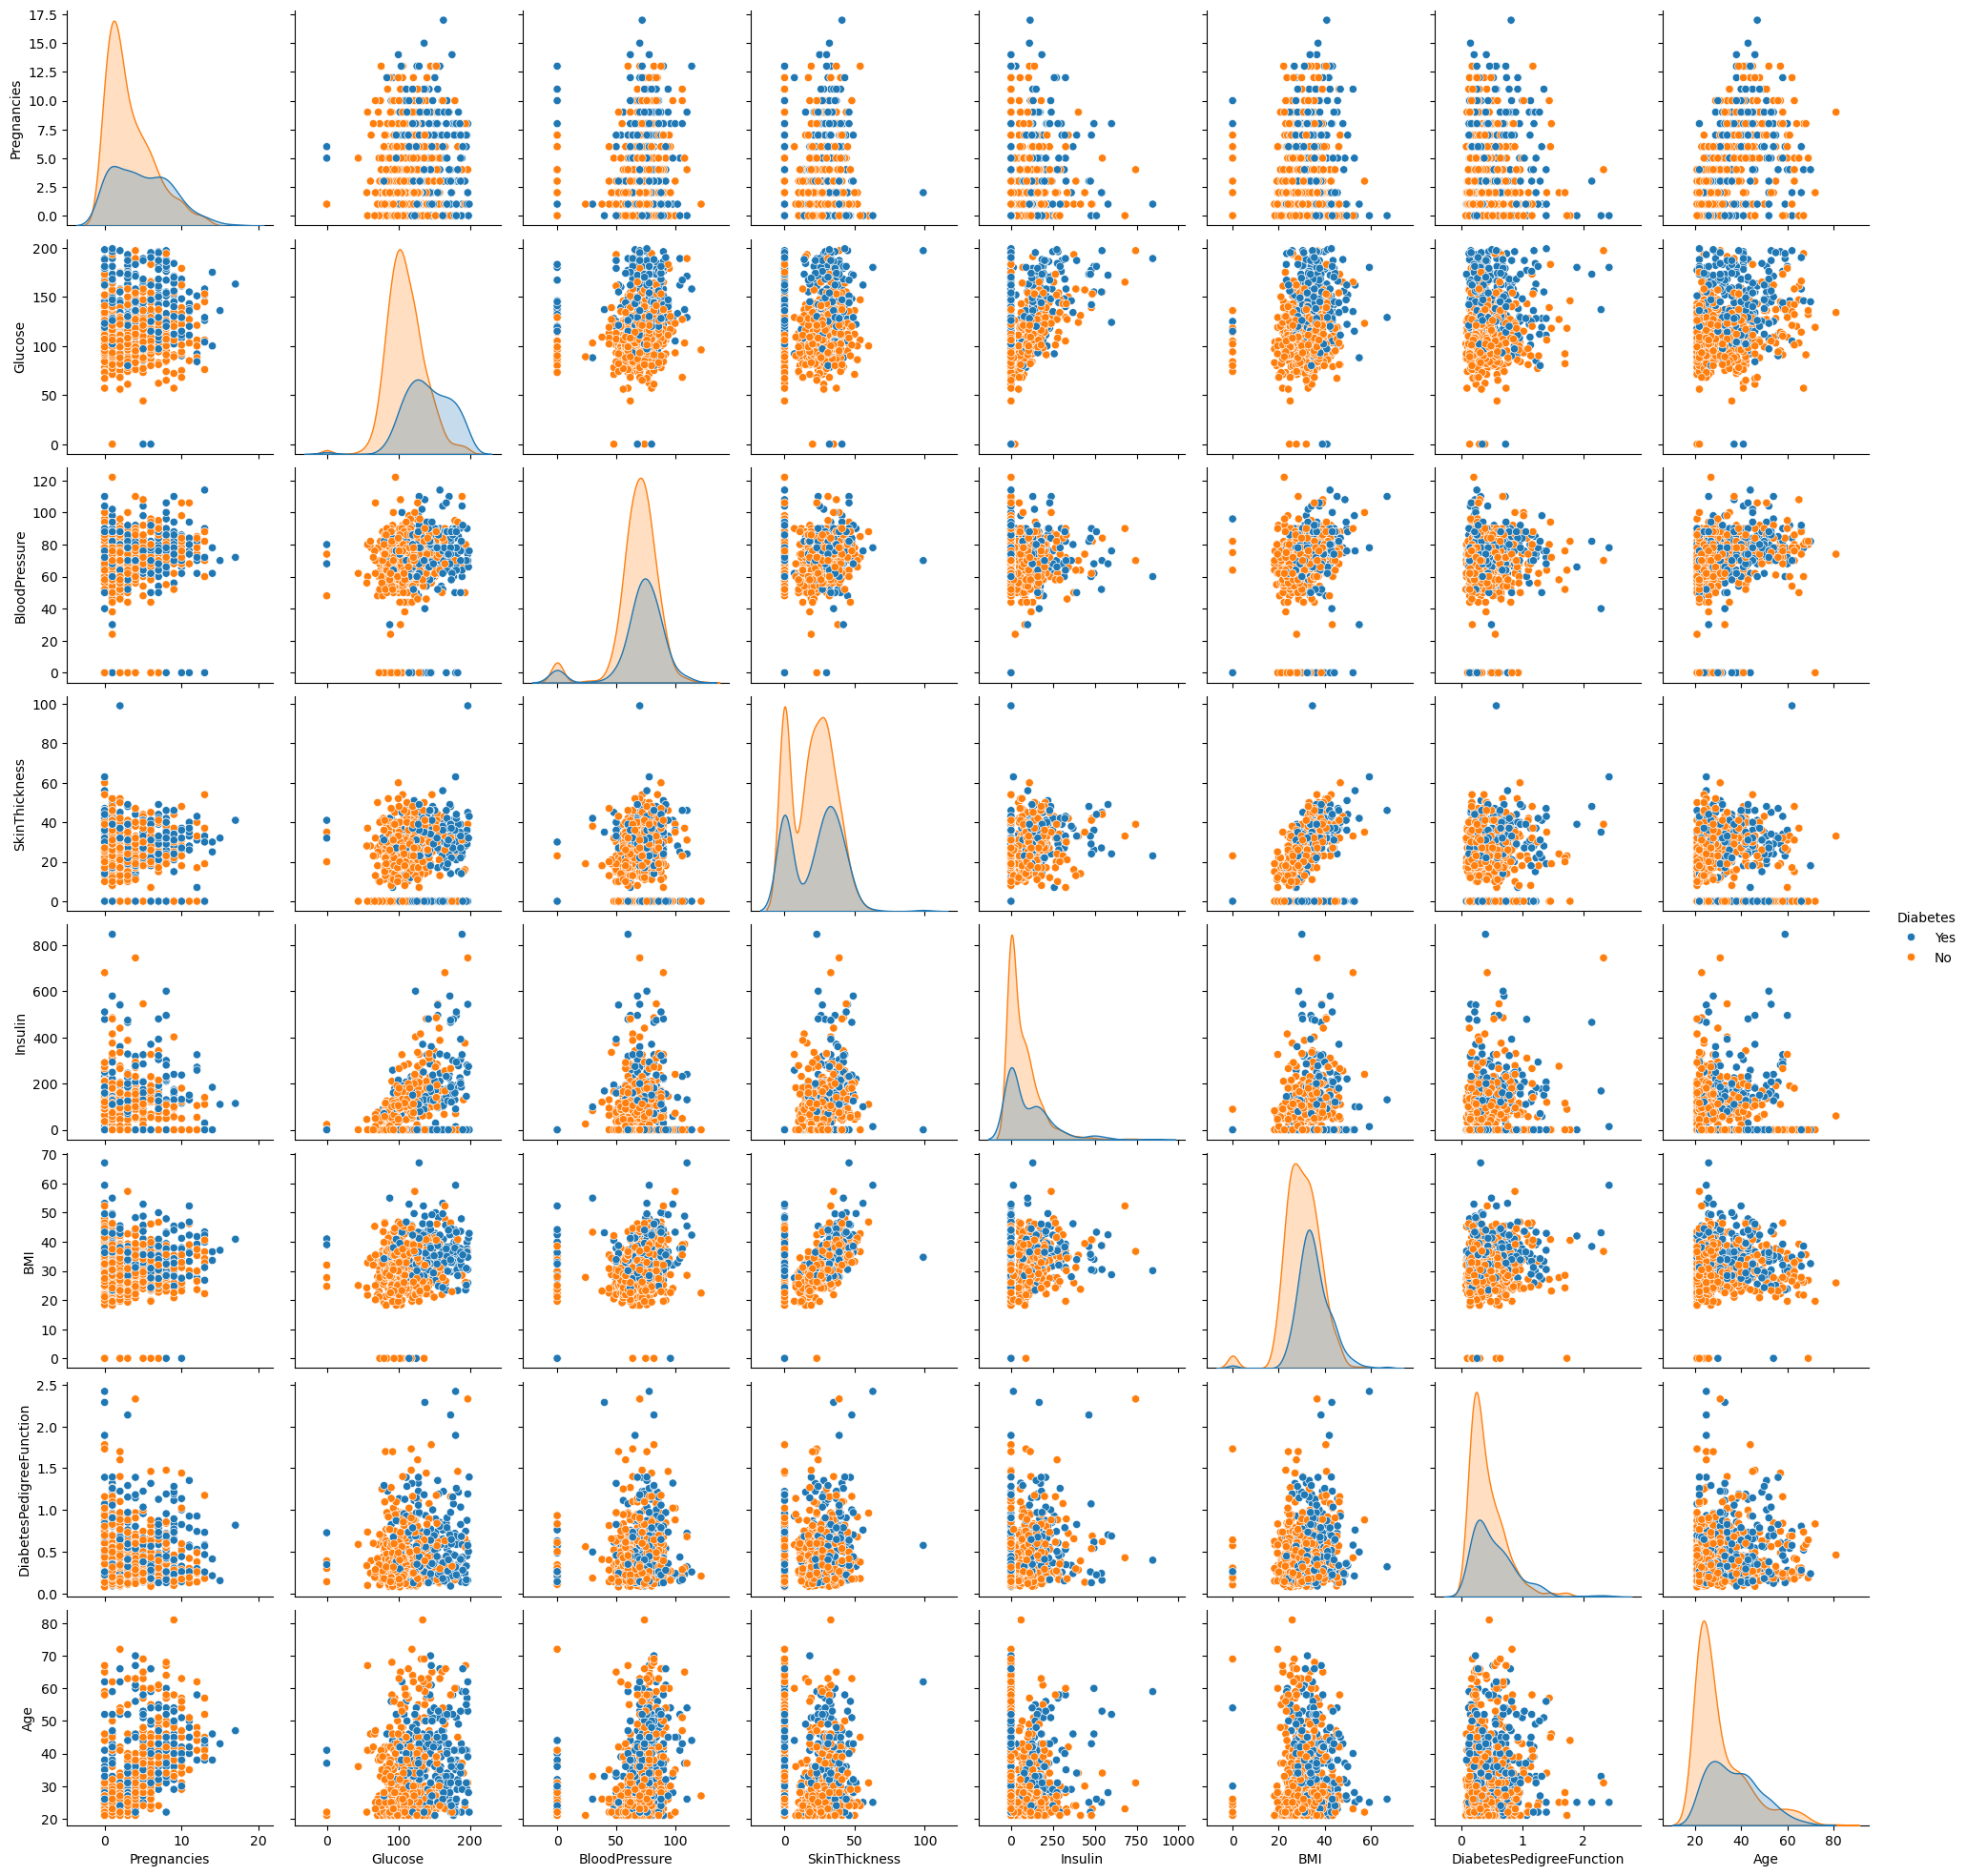

In [6]:
(sns.pairplot(diabetes.to_pandas(), hue = 'Diabetes'))

In [7]:
log_reg = LogisticRegression(max_iter=100000)
knn = KNeighborsClassifier()
nb = GaussianNB()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

In [8]:
(X_diabetes := 
diabetes.drop('Diabetes')
 .to_pandas()
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [10]:
(y_diabetes_raw := 
diabetes.select('Diabetes')
)

Diabetes
str
"""Yes"""
"""No"""
"""Yes"""
"""No"""
"""Yes"""
…
"""No"""
"""No"""
"""No"""


In [11]:
(uniq_labels :=
 y_diabetes_raw
 .unique() # Make sure the positive case is first
 .sort("Diabetes", descending=True)
 .get_column('Diabetes')
 .to_numpy()

)

array(['Yes', 'No'], dtype=object)

In [13]:
le = LabelEncoder()
le.fit(uniq_labels)

(y_ind :=
  le.transform(y_diabetes_raw.get_column('Diabetes'))
)

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [14]:
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_diabetes,y_ind, test_size=0.3, random_state=42) 

In [15]:
(cross_validate(log_reg,X_diabetes, y_ind,cv =folds,scoring = my_scores)

            >> rec.map(np.mean)
)


{'fit_time': np.float64(0.043852949142456056),
 'score_time': np.float64(0.008466005325317383),
 'test_accuracy': np.float64(0.7707919531448943),
 'test_balanced_accuracy': np.float64(0.7236827393431168),
 'test_f1': np.float64(0.6332858481118071),
 'test_precision': np.float64(0.7238670733535946),
 'test_recall': np.float64(0.5673654786862333),
 'test_roc_auc': np.float64(0.8301229909154436)}

In [16]:
(cross_validate(knn,X_diabetes, y_ind,cv =folds,scoring = my_scores) 

 >>rec.map(np.mean)
)

{'fit_time': np.float64(0.0055542469024658205),
 'score_time': np.float64(0.013727664947509766),
 'test_accuracy': np.float64(0.6978694508106273),
 'test_balanced_accuracy': np.float64(0.6528169112508735),
 'test_f1': np.float64(0.5380213788369128),
 'test_precision': np.float64(0.5779130434782609),
 'test_recall': np.float64(0.503633822501747),
 'test_roc_auc': np.float64(0.731893431167016)}

In [17]:
(cross_validate(nb, X_diabetes, y_ind, cv = folds, scoring =my_scores)
 >>rec.map(np.mean)
 )

{'fit_time': np.float64(0.003982639312744141),
 'score_time': np.float64(0.013316535949707031),
 'test_accuracy': np.float64(0.7551650963415669),
 'test_balanced_accuracy': np.float64(0.7236086652690427),
 'test_f1': np.float64(0.6391530288417947),
 'test_precision': np.float64(0.6620429488186457),
 'test_recall': np.float64(0.6192173305380853),
 'test_roc_auc': np.float64(0.8092851153039833)}

In [18]:
(cross_validate(lda, X_diabetes, y_ind, cv = folds, scoring =my_scores)
  >> rec.map(np.mean)
 
 )

{'fit_time': np.float64(0.0061133384704589845),
 'score_time': np.float64(0.015618324279785156),
 'test_accuracy': np.float64(0.7655886597063069),
 'test_balanced_accuracy': np.float64(0.7179440950384347),
 'test_f1': np.float64(0.6245924594093931),
 'test_precision': np.float64(0.7122228648544437),
 'test_recall': np.float64(0.5598881900768693),
 'test_roc_auc': np.float64(0.8307665967854646)}

In [19]:
(cross_validate(qda, X_diabetes, y_ind,cv = folds, scoring =my_scores)
            >> rec.map(np.mean)
)

{'fit_time': np.float64(0.008844804763793946),
 'score_time': np.float64(0.015971040725708006),
 'test_accuracy': np.float64(0.7343858755623461),
 'test_balanced_accuracy': np.float64(0.6963598881900769),
 'test_f1': np.float64(0.6005874144691348),
 'test_precision': np.float64(0.6369806593062407),
 'test_recall': np.float64(0.5707197763801537),
 'test_roc_auc': np.float64(0.8014842767295598)}

In [22]:
all_results = {
    'Logistic Regression': {'test_accuracy': 0.7707, 'test_roc_auc': 0.8301, 'test_recall': 0.5673},
    'kNN': {'test_accuracy': 0.6978, 'test_roc_auc': 0.7318, 'test_recall': 0.5036},
    'Naive Bayes': {'test_accuracy': 0.7551, 'test_roc_auc': 0.8092, 'test_recall': 0.6192},
    'LDA': {'test_accuracy': 0.7655, 'test_roc_auc': 0.8307, 'test_recall': 0.5634}, 
    'QDA': {'test_accuracy': 0.7343, 'test_roc_auc': 0.8014, 'test_recall': 0.5707}
}

df_results = pd.DataFrame(all_results).T

best_model_name = df_results['test_roc_auc'].idxmax()
best_auc_value = df_results['test_roc_auc'].max()

print(f"The best model based on AUC is: {best_model_name} with a score of {best_auc_value:.4f}")

The best model based on AUC is: LDA with a score of 0.8307


## Best scores

#### The LDA was the best ROC AUC score with 0.83, with Log Reg being a close second and NB a distant third.

## Activity 3.4

In [18]:
(diabetes_raw :=

    pl.read_csv('./sample_data/diabetes_raw.csv')

)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
i64,i64,i64,i64,i64,f64,f64,i64,str
6,148,72,35,0,33.6,0.627,50,"""Yes"""
1,85,66,29,0,26.6,0.351,31,"""No"""
8,183,64,0,0,23.3,0.672,32,"""Yes"""
1,89,66,23,94,28.1,0.167,21,"""No"""
0,137,40,35,168,43.1,2.288,33,"""Yes"""
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,"""No"""
2,122,70,27,0,36.8,0.34,27,"""No"""
5,121,72,23,112,26.2,0.245,30,"""No"""


In [19]:
(X :=
 diabetes_raw
 .drop('Diabetes')
 .to_pandas()
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [20]:
(y_raw :=
 diabetes_raw
 .select('Diabetes')
)

Diabetes
str
"""Yes"""
"""No"""
"""Yes"""
"""No"""
"""Yes"""
…
"""No"""
"""No"""
"""No"""


In [21]:
(uniq_labels :=
 y_raw
 .unique() # Make sure the positive case is first
 .sort("Diabetes", descending=True)
 .get_column('Diabetes')
 .to_numpy()

)

array(['Yes', 'No'], dtype=object)

In [22]:
le = LabelEncoder()
le.fit(uniq_labels)

(y_ind :=
  le.transform(y_raw.get_column('Diabetes'))
)

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y_ind, test_size=0.30,random_state=42, stratify=y_ind)

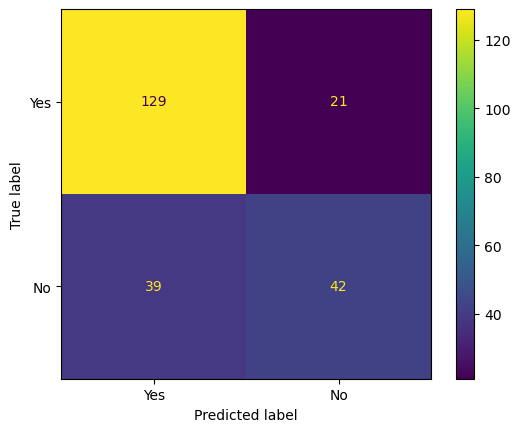

In [24]:
log_reg.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, display_labels=uniq_labels)


In [25]:
(y_pred := log_reg.predict(X_test))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
(tn, fp, fn, tp)
#sensitvity log regression
(sensitivity := tp / (tp + fn))

#specificity log reg
(specificity := tn / (tn+fp))


print(sensitivity,specificity)

0.5185185185185185 0.86


In [27]:
kNN = KNeighborsClassifier()
grid_knn = {'n_neighbors':list(range(3,12, 2))}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

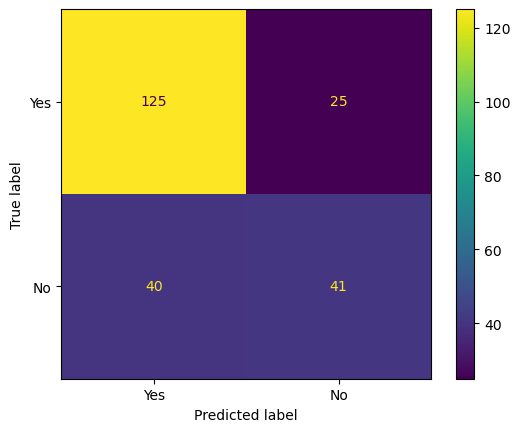

In [28]:
kNN.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(kNN, X_test, y_test, display_labels = uniq_labels)

### Defining the other classifiers

In [35]:
nb = GaussianNB()
nb.fit(X_train, y_train)



,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [38]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)



,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [39]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)



,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


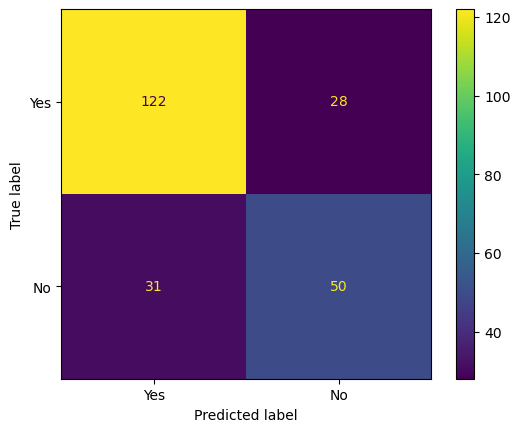

In [36]:
ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test, display_labels = uniq_labels)

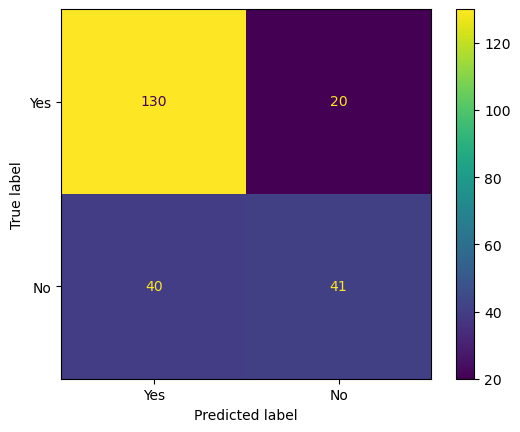

In [40]:
ConfusionMatrixDisplay.from_estimator(lda, X_test, y_test, display_labels = uniq_labels)

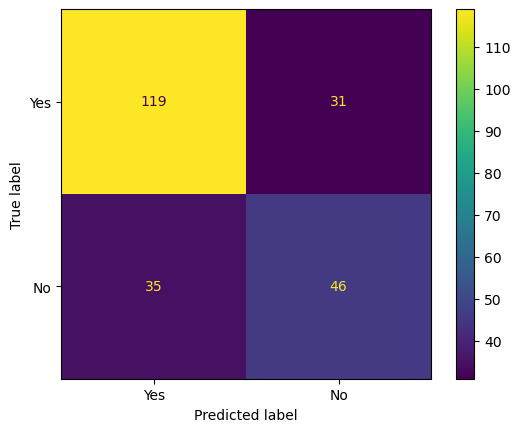

In [41]:
ConfusionMatrixDisplay.from_estimator(qda, X_test, y_test, display_labels = uniq_labels)

### The ROC curves

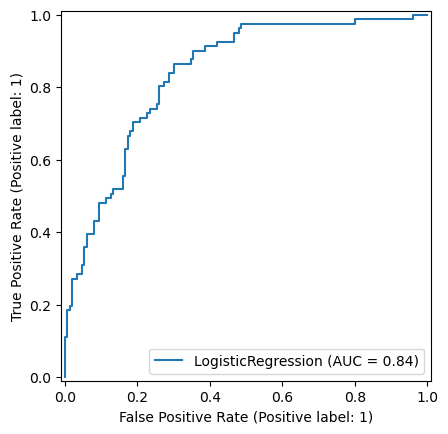

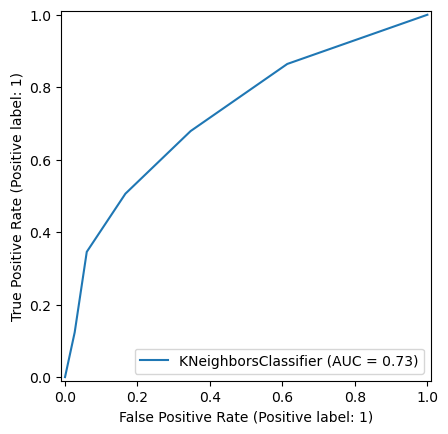

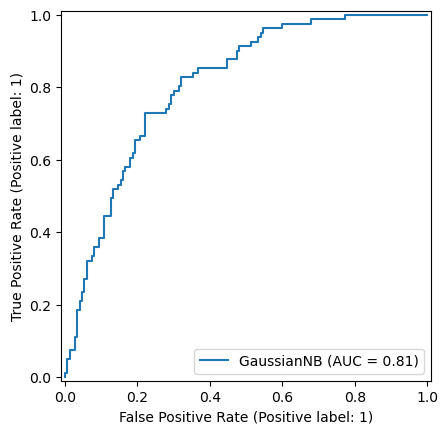

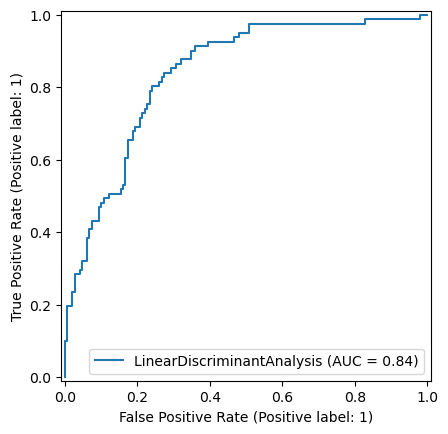

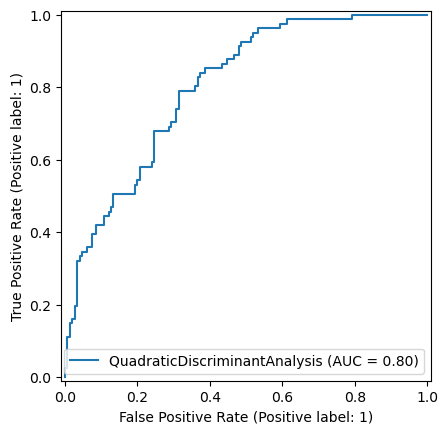

In [42]:
(log_reg_disp := RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
 )

(knn_disp := RocCurveDisplay.from_estimator(kNN, X_test, y_test))

(nb_disp := RocCurveDisplay.from_estimator(nb,X_test, y_test))

(lda_disp := RocCurveDisplay.from_estimator(lda,X_test, y_test))

(qda_disp := RocCurveDisplay.from_estimator(qda, X_test, y_test))

##### Overlaid

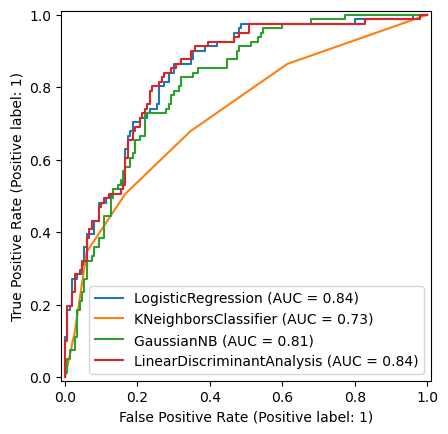

In [44]:
ax = plt.gca()
log_reg_disp.plot(ax=ax)
knn_disp.plot(ax=ax)
nb_disp.plot(ax= ax)
lda_disp.plot(ax= ax)

##### The model with the best AUC from the ROC curves would be Logistic Regression and Linear Discriminant Analysis

In [45]:
#Sensitivity for Logistic 
(y_pred_log := log_reg.predict(X_test))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_log).ravel().tolist()
(tn, fp, fn, tp)
#sensitvity log regression
(sensitivity := tp / (tp + fn))

#specificity log reg
(specificity := tn / (tn+fp))


print(sensitivity,specificity)

0.5185185185185185 0.86


In [46]:
(y_pred_lda := lda.predict(X_test))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lda).ravel().tolist()

#sensitivity lda 
(sensitivity := tp /(tp + fn))

#specificity
(specficity := tn / (tn +fp))


print(sensitivity,specificity)

0.5061728395061729 0.86
